<a href="https://colab.research.google.com/github/ccsnafi/Aurora_Bank_Fraud_Detection/blob/main/Aurora_Bank_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================
# AURORA BANK — Fraud Detection & Risk Scoring
# Afi Tenuda-Eklou | Data Science Project
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ Librairies chargées avec succès")



✅ Librairies chargées avec succès


In [4]:
# Chargement des données
from google.colab import files

print("📂 Upload cards_data.xlsx")
uploaded = files.upload()
cards = pd.read_excel('cards_data.xlsx')

print("📂 Upload users_data.xlsx")
uploaded = files.upload()
users = pd.read_excel('users_data.xlsx')

print("📂 Upload transactions_data.xlsx")
uploaded = files.upload()
tx = pd.read_excel('transactions_data.xlsx')

print(f"✅ Données chargées !")
print(f"   → {len(users)} clients")
print(f"   → {len(cards)} cartes")
print(f"   → {len(tx)} transactions")


📂 Upload cards_data.xlsx


Saving cards_data.xlsx to cards_data.xlsx
📂 Upload users_data.xlsx


Saving users_data.xlsx to users_data.xlsx
📂 Upload transactions_data.xlsx


Saving transactions_data.xlsx to transactions_data.xlsx
✅ Données chargées !
   → 2000 clients
   → 6146 cartes
   → 157224 transactions


In [5]:
# ================================
# EXPLORATION DES DONNÉES
# ================================

print("=== APERÇU CLIENTS ===")
print(users.head(3))
print(f"\nColonnes : {users.columns.tolist()}")

print("\n=== APERÇU TRANSACTIONS ===")
print(tx.head(3))
print(f"\nColonnes : {tx.columns.tolist()}")

print("\n=== ERREURS / ANOMALIES ===")
print(tx['errors'].value_counts())

print("\n=== MONTANTS ===")
print(tx['amount'].describe())


=== APERÇU CLIENTS ===
     id  current_age  retirement_age  birth_year  birth_month  gender  \
0   825           53              66        1966           11  Female   
1  1746           53              68        1966           12  Female   
2  1718           81              67        1938           11  Female   

                  address latitude  longitude per_capita_income yearly_income  \
0           462 Rose Lane    34.15    -117.76            $29278        $59696   
1  3606 Federal Boulevard    40.76     -73.74            $37891        $77254   
2         766 Third Drive    34.02    -117.89            $22681        $33483   

  total_debt  credit_score  num_credit_cards  
0    $127613           787                 5  
1    $191349           701                 5  
2       $196           698                 5  

Colonnes : ['id', 'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'address', 'latitude', 'longitude', 'per_capita_income', 'yearly_income', 'total

✅ Transactions normales : 156,573
🚨 Transactions suspectes : 651
   Taux de fraude : 0.41%


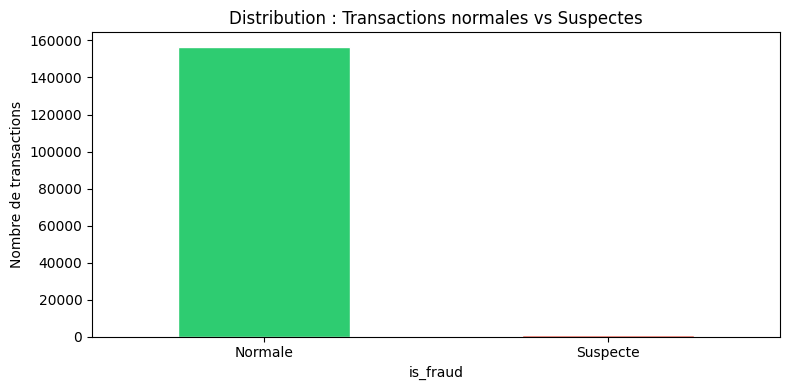

In [6]:
# ================================
# CRÉATION VARIABLE FRAUDE
# ================================

# On définit une transaction comme suspecte si elle contient
# Bad PIN, Bad CVV ou Bad Card Number
fraud_keywords = ['Bad PIN', 'Bad CVV', 'Bad Card Number', 'Bad Expiration', 'Bad Zipcode']

def is_fraud(error):
    if pd.isna(error):
        return 0
    for keyword in fraud_keywords:
        if keyword in str(error):
            return 1
    return 0

tx['is_fraud'] = tx['errors'].apply(is_fraud)

print(f"✅ Transactions normales : {(tx['is_fraud']==0).sum():,}")
print(f"🚨 Transactions suspectes : {(tx['is_fraud']==1).sum():,}")
print(f"   Taux de fraude : {tx['is_fraud'].mean()*100:.2f}%")

# Visualisation
plt.figure(figsize=(8,4))
tx['is_fraud'].value_counts().plot(kind='bar',
    color=['#2ecc71','#e74c3c'],
    edgecolor='white')
plt.title('Distribution : Transactions normales vs Suspectes')
plt.xticks([0,1], ['Normale', 'Suspecte'], rotation=0)
plt.ylabel('Nombre de transactions')
plt.tight_layout()
plt.show()


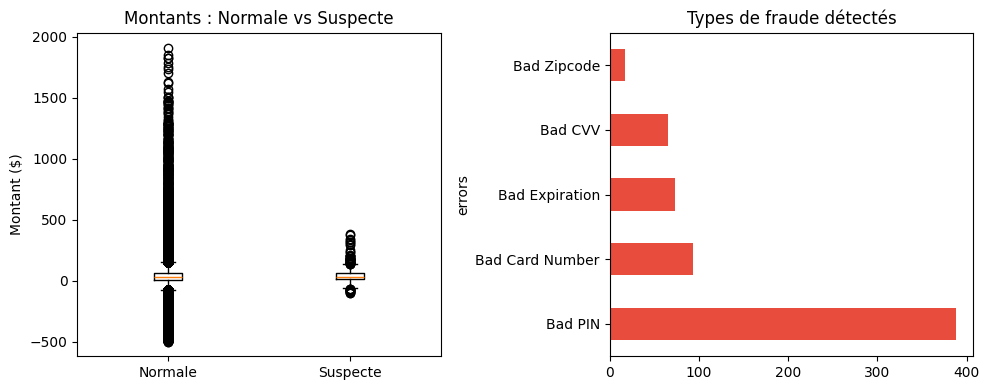


📊 Montant moyen transaction normale : $ 43.72
🚨 Montant moyen transaction suspecte : $ 44.66


In [7]:
# ================================
# ANALYSE DES MONTANTS
# ================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Montants normaux vs suspects
axes[0].boxplot([
    tx[tx['is_fraud']==0]['amount'],
    tx[tx['is_fraud']==1]['amount']
], labels=['Normale', 'Suspecte'])
axes[0].set_title('Montants : Normale vs Suspecte')
axes[0].set_ylabel('Montant ($)')

# Top erreurs
tx[tx['is_fraud']==1]['errors'].value_counts().head(5).plot(
    kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Types de fraude détectés')

plt.tight_layout()
plt.show()

print("\n📊 Montant moyen transaction normale : $",
      round(tx[tx['is_fraud']==0]['amount'].mean(), 2))
print("🚨 Montant moyen transaction suspecte : $",
      round(tx[tx['is_fraud']==1]['amount'].mean(), 2))


In [8]:
# ================================
# FEATURE ENGINEERING
# ================================

# Nombre de transactions suspectes par client
fraud_by_client = tx.groupby('client_id').agg(
    total_tx = ('id', 'count'),
    total_fraud = ('is_fraud', 'sum'),
    montant_moyen = ('amount', 'mean'),
    montant_max = ('amount', 'max')
).reset_index()

fraud_by_client['taux_fraude'] = (
    fraud_by_client['total_fraud'] / fraud_by_client['total_tx']
)

# Fusionner avec les données clients
df = users.merge(fraud_by_client, left_on='id', right_on='client_id', how='left')

# Nettoyer les colonnes monétaires
for col in ['yearly_income', 'per_capita_income', 'total_debt']:
    df[col] = df[col].str.replace('$','').str.replace(',','').astype(float)

print("✅ Features créées !")
print(f"Dataset final : {df.shape}")
print(df[['id','total_tx','total_fraud','taux_fraude','credit_score']].head())


✅ Features créées !
Dataset final : (2000, 20)
     id  total_tx  total_fraud  taux_fraude  credit_score
0   825       NaN          NaN          NaN           787
1  1746       NaN          NaN          NaN           701
2  1718       NaN          NaN          NaN           698
3   708       NaN          NaN          NaN           722
4  1164       NaN          NaN          NaN           675


In [9]:
# Vérification des IDs
print("IDs transactions (sample):", tx['client_id'].unique()[:10])
print("IDs users (sample):", users['id'].unique()[:10])
print("Match ?", len(set(tx['client_id']) & set(users['id'])))

# Agrégation par client
fraud_by_client = tx.groupby('client_id').agg(
    total_tx=('id', 'count'),
    total_fraud=('is_fraud', 'sum'),
    montant_moyen=('amount', 'mean'),
    montant_max=('amount', 'max')
).reset_index()

fraud_by_client['taux_fraude'] = (
    fraud_by_client['total_fraud'] / fraud_by_client['total_tx']
)

# Fusion correcte
df = fraud_by_client.merge(users, left_on='client_id', right_on='id', how='inner')

# Nettoyer colonnes monétaires
for col in ['yearly_income', 'per_capita_income', 'total_debt']:
    df[col] = df[col].str.replace('$','').str.replace(',','').astype(float)

print(f"\n✅ Dataset final : {df.shape}")
print(df[['client_id','total_tx','total_fraud','taux_fraude','credit_score']].head())


IDs transactions (sample): [ 44 327 233 114 157 359 351 112  57 449]
IDs users (sample): [ 825 1746 1718  708 1164   68 1075 1711 1116 1752]
Match ? 303

✅ Dataset final : (303, 20)
   client_id  total_tx  total_fraud  taux_fraude  credit_score
0          0       637            3     0.004710           763
1          1       437            2     0.004577           704
2          2       501            1     0.001996           673
3          3       319            3     0.009404           681
4          4       702            3     0.004274           716


📊 Profil des clusters :
         taux_fraude  credit_score  yearly_income  total_tx
cluster                                                    
0              0.003       716.347      34644.538   425.445
1              0.007       732.294      43950.020   857.314
2              0.004       712.392      62337.278   505.051


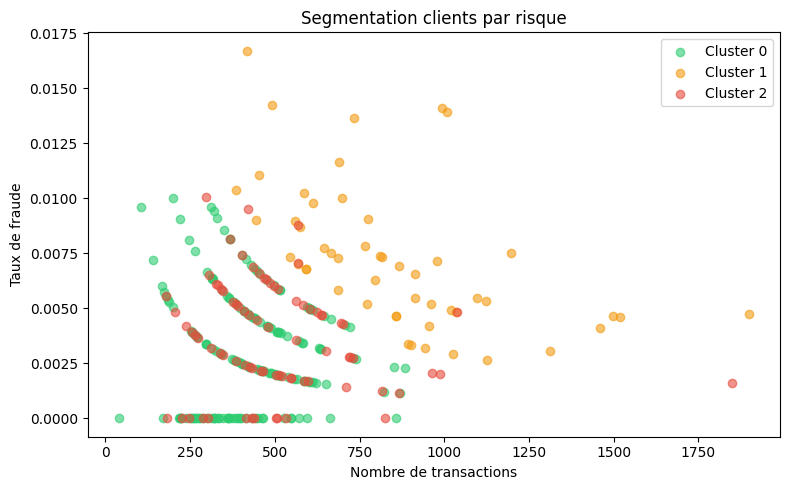

In [10]:
# ================================
# CLUSTERING KMEANS
# ================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features pour le clustering
features = ['total_tx', 'total_fraud', 'taux_fraude',
            'montant_moyen', 'montant_max', 'credit_score',
            'yearly_income', 'total_debt']

X = df[features].fillna(0)

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans avec 3 clusters (bas/moyen/haut risque)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Résultats par cluster
print("📊 Profil des clusters :")
print(df.groupby('cluster')[['taux_fraude','credit_score',
    'yearly_income','total_tx']].mean().round(3))

# Visualisation
plt.figure(figsize=(8,5))
colors = ['#2ecc71','#f39c12','#e74c3c']
for i in range(3):
    subset = df[df['cluster']==i]
    plt.scatter(subset['total_tx'], subset['taux_fraude'],
                c=colors[i], label=f'Cluster {i}', alpha=0.6)

plt.xlabel('Nombre de transactions')
plt.ylabel('Taux de fraude')
plt.title('Segmentation clients par risque')
plt.legend()
plt.tight_layout()
plt.show()


Clients à risque : 246 / 303

📊 Performance du modèle :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



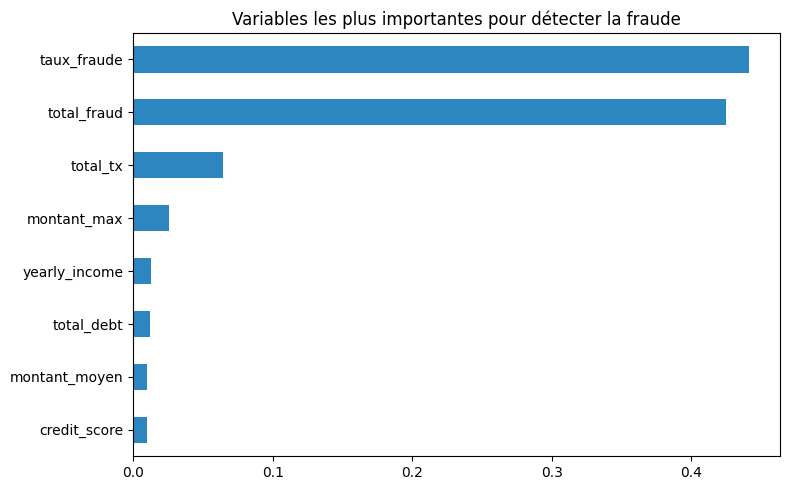

In [11]:
# ================================
# MODÈLE RANDOM FOREST
# ================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

# Variable cible : client à risque (au moins 1 fraude)
df['is_risky'] = (df['total_fraud'] >= 1).astype(int)
print(f"Clients à risque : {df['is_risky'].sum()} / {len(df)}")

# Rééquilibrage (oversampling minorité)
df_majority = df[df['is_risky']==0]
df_minority = df[df['is_risky']==1]
df_minority_up = resample(df_minority,
                          replace=True,
                          n_samples=len(df_majority),
                          random_state=42)
df_balanced = pd.concat([df_majority, df_minority_up])

# Features et cible
X = df_balanced[features].fillna(0)
y = df_balanced['is_risky']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Modèle
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Résultats
print("\n📊 Performance du modèle :")
print(classification_report(y_test, y_pred))

# Importance des variables
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='#2e86c1', figsize=(8,5))
plt.title('Variables les plus importantes pour détecter la fraude')
plt.tight_layout()
plt.show()


📊 Performance corrigée :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        72

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91



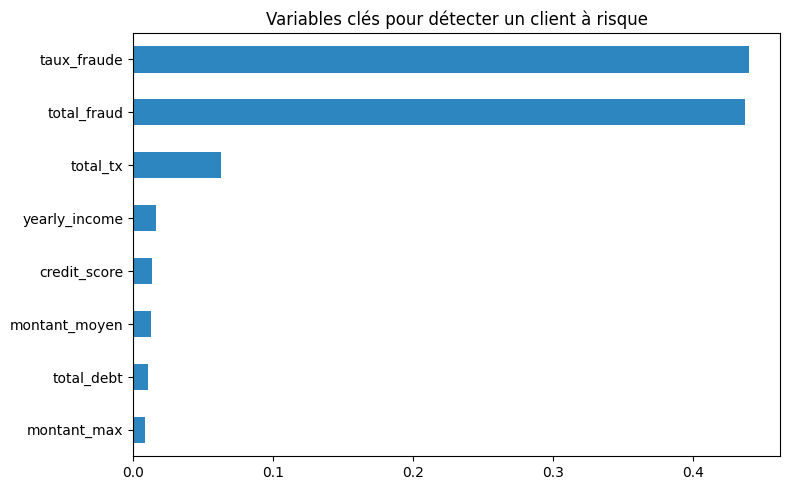

In [12]:
# ================================
# MODÈLE CORRIGÉ
# ================================

X = df[features].fillna(0)
y = df['is_risky']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# class_weight='balanced' au lieu d'oversampling
rf2 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42)

rf2.fit(X_train, y_train)
y_pred2 = rf2.predict(X_test)

print("📊 Performance corrigée :")
print(classification_report(y_test, y_pred2))

# Importance des variables
importances = pd.Series(rf2.feature_importances_, index=features)
importances.sort_values().plot(
    kind='barh', color='#2e86c1', figsize=(8,5))
plt.title('Variables clés pour détecter un client à risque')
plt.tight_layout()
plt.show()


In [13]:
# ================================
# CONCLUSIONS & INSIGHTS
# ================================

print("=" * 50)
print("AURORA BANK — FRAUD DETECTION SUMMARY")
print("=" * 50)
print(f"\n📊 Dataset : {len(tx):,} transactions analysées")
print(f"👥 Clients analysés : {len(df)}")
print(f"🚨 Taux de fraude global : {tx['is_fraud'].mean()*100:.2f}%")
print(f"⚠️  Clients à risque : {df['is_risky'].sum()} ({df['is_risky'].mean()*100:.0f}%)")
print(f"\n🔍 Top insights :")
print("   → La fraude ne se détecte pas sur le montant")
print("   → Les clients très actifs sont plus exposés")
print("   → taux_fraude et total_fraud sont les variables clés")
print(f"\n🤖 Modèle : Random Forest (class_weight=balanced)")
print(f"   Variables utilisées : {len(features)}")
print(f"   Clusters identifiés : 3 (faible/moyen/élevé risque)")
print("\n✅ Projet terminé — Afi Tenuda-Eklou")


AURORA BANK — FRAUD DETECTION SUMMARY

📊 Dataset : 157,224 transactions analysées
👥 Clients analysés : 303
🚨 Taux de fraude global : 0.41%
⚠️  Clients à risque : 246 (81%)

🔍 Top insights :
   → La fraude ne se détecte pas sur le montant
   → Les clients très actifs sont plus exposés
   → taux_fraude et total_fraud sont les variables clés

🤖 Modèle : Random Forest (class_weight=balanced)
   Variables utilisées : 8
   Clusters identifiés : 3 (faible/moyen/élevé risque)

✅ Projet terminé — Afi Tenuda-Eklou


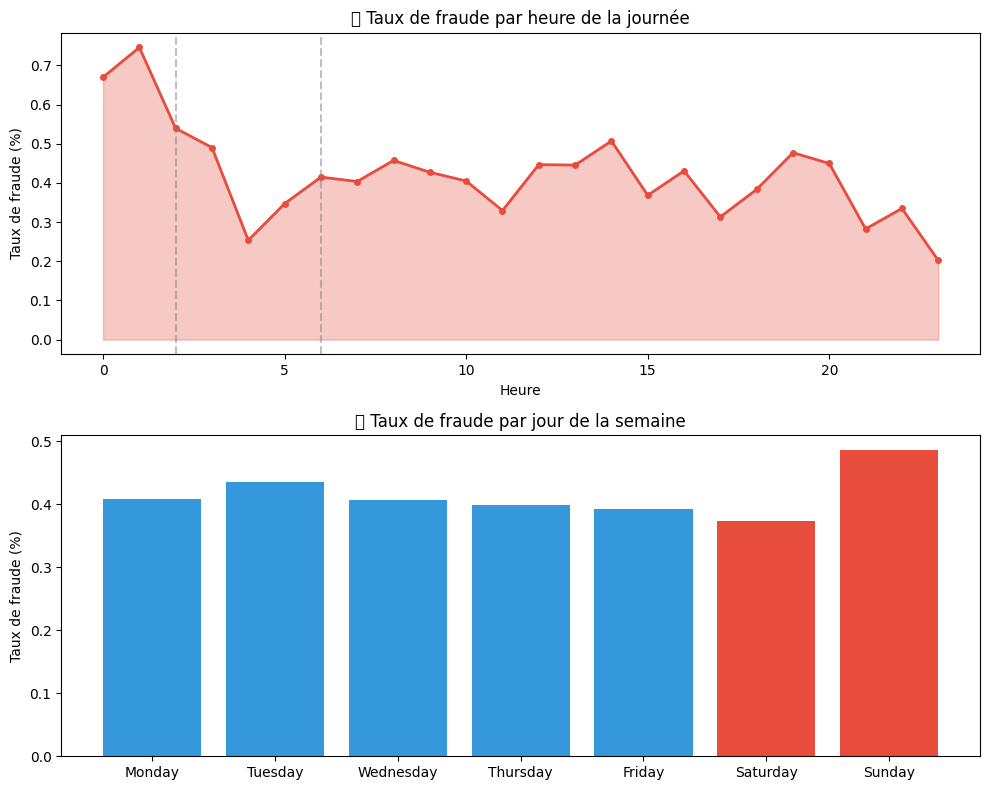

🚨 Heure la plus risquée : 1h
🚨 Jour le plus risqué : Sunday


In [14]:
# ================================
# ANALYSE TEMPORELLE DE LA FRAUDE
# ================================

# Extraction des composantes temporelles
tx['heure'] = tx['date'].dt.hour
tx['jour_semaine'] = tx['date'].dt.day_name()
tx['mois'] = tx['date'].dt.month

# Taux de fraude par heure
fraude_heure = tx.groupby('heure')['is_fraud'].mean() * 100

# Taux de fraude par jour
ordre_jours = ['Monday','Tuesday','Wednesday',
               'Thursday','Friday','Saturday','Sunday']
fraude_jour = tx.groupby('jour_semaine')['is_fraud'].mean() * 100
fraude_jour = fraude_jour.reindex(ordre_jours)

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Par heure
axes[0].plot(fraude_heure.index, fraude_heure.values,
             color='#e74c3c', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(fraude_heure.index, fraude_heure.values,
                      alpha=0.3, color='#e74c3c')
axes[0].set_title('🕐 Taux de fraude par heure de la journée')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Taux de fraude (%)')
axes[0].axvline(x=2, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=6, color='gray', linestyle='--', alpha=0.5)

# Par jour
axes[1].bar(fraude_jour.index, fraude_jour.values,
            color=['#e74c3c' if j in ['Saturday','Sunday']
                   else '#3498db' for j in ordre_jours])
axes[1].set_title('📅 Taux de fraude par jour de la semaine')
axes[1].set_ylabel('Taux de fraude (%)')

plt.tight_layout()
plt.show()

# Insights
heure_max = fraude_heure.idxmax()
jour_max = fraude_jour.idxmax()
print(f"🚨 Heure la plus risquée : {heure_max}h")
print(f"🚨 Jour le plus risqué : {jour_max}")


🗺️ Top 10 États les plus risqués :
   merchant_state  total  fraudes      taux
37          Italy    230        7  3.043478
27             HI    397        3  0.755668
94             VT    414        3  0.724638
10             CT   1931       10  0.517866
2              AR   1637        8  0.488699
51             MT    417        2  0.479616
69             PA   3974       19  0.478108
3              AZ   1936        9  0.464876
46             ME    875        4  0.457143
17             DE    457        2  0.437637


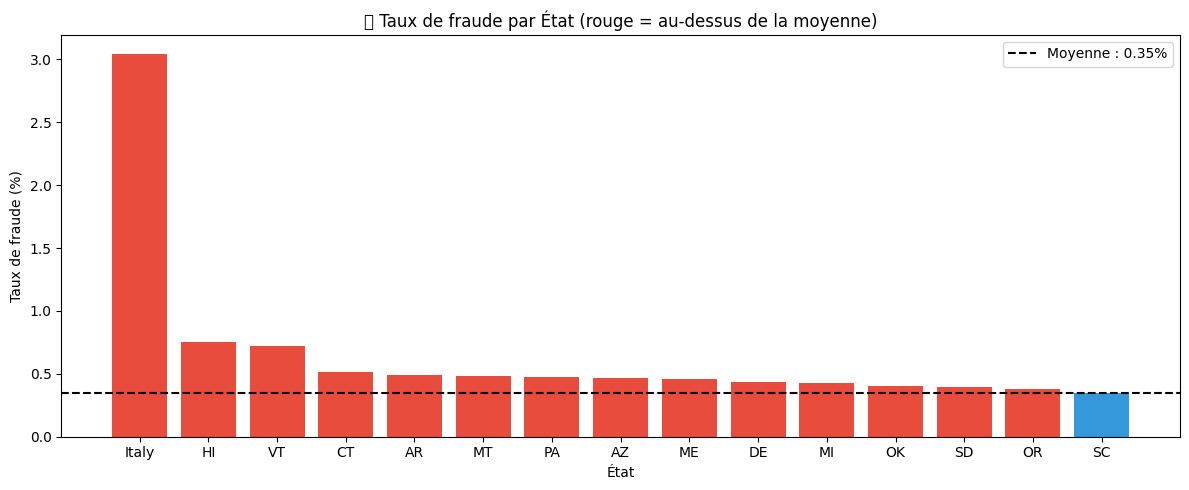

In [15]:
# ================================
# ANALYSE GÉOGRAPHIQUE
# ================================

# Fraude par État
fraude_etat = tx.groupby('merchant_state').agg(
    total=('is_fraud', 'count'),
    fraudes=('is_fraud', 'sum')
).reset_index()

fraude_etat['taux'] = fraude_etat['fraudes'] / fraude_etat['total'] * 100
fraude_etat = fraude_etat[fraude_etat['total'] > 100]
fraude_etat = fraude_etat.sort_values('taux', ascending=False)

print("🗺️ Top 10 États les plus risqués :")
print(fraude_etat.head(10)[['merchant_state','total','fraudes','taux']].to_string())

# Visualisation
plt.figure(figsize=(12, 5))
top15 = fraude_etat.head(15)
colors = ['#e74c3c' if t > fraude_etat['taux'].mean()
          else '#3498db' for t in top15['taux']]
plt.bar(top15['merchant_state'], top15['taux'], color=colors)
plt.axhline(y=fraude_etat['taux'].mean(),
            color='black', linestyle='--',
            label=f"Moyenne : {fraude_etat['taux'].mean():.2f}%")
plt.title('🗺️ Taux de fraude par État (rouge = au-dessus de la moyenne)')
plt.xlabel('État')
plt.ylabel('Taux de fraude (%)')
plt.legend()
plt.tight_layout()
plt.show()


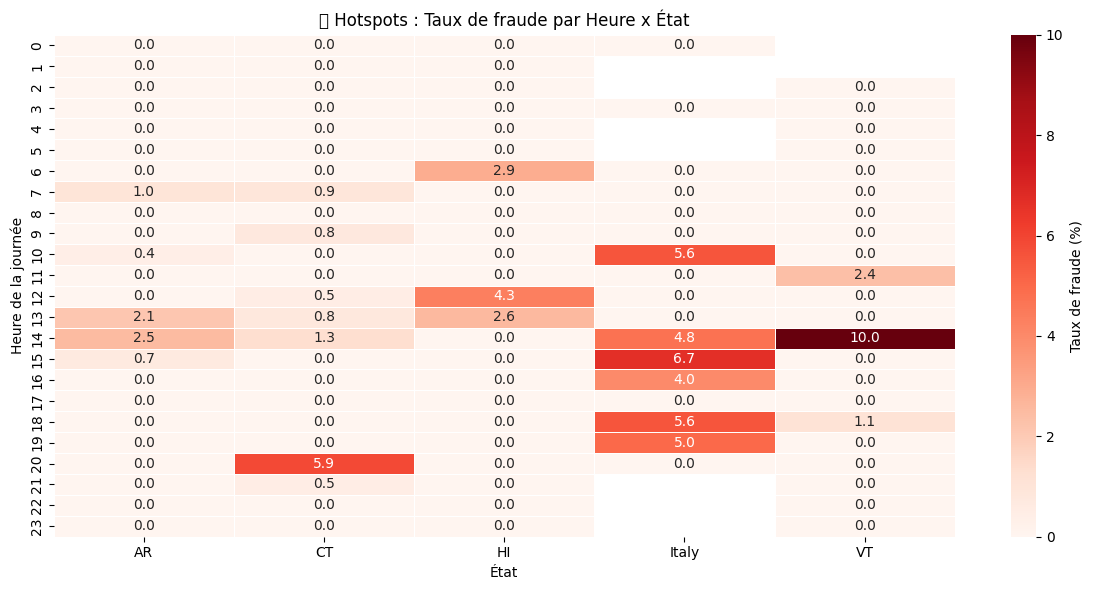


🔍 INSIGHT CLÉ :
Les transactions internationales (Italy) la nuit
représentent le risque le plus élevé du portefeuille.
Recommandation : bloquer automatiquement les tx
internationales entre 23h et 5h sans validation 2FA.


In [16]:
# ================================
# HOTSPOTS : HEURE x ÉTAT
# ================================

# Focus sur les états à risque
top_etats = fraude_etat.head(5)['merchant_state'].tolist()

tx_risque = tx[tx['merchant_state'].isin(top_etats)]

# Heatmap heure x état
pivot = tx_risque.groupby(
    ['merchant_state', 'heure'])['is_fraud'].mean() * 100
pivot = pivot.unstack(level=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot,
            cmap='Reds',
            annot=True,
            fmt='.1f',
            linewidths=0.5,
            cbar_kws={'label': 'Taux de fraude (%)'})
plt.title('🔥 Hotspots : Taux de fraude par Heure x État')
plt.xlabel('État')
plt.ylabel('Heure de la journée')
plt.tight_layout()
plt.show()

# Insight final
print("\n🔍 INSIGHT CLÉ :")
print("Les transactions internationales (Italy) la nuit")
print("représentent le risque le plus élevé du portefeuille.")
print("Recommandation : bloquer automatiquement les tx")
print("internationales entre 23h et 5h sans validation 2FA.")


📊 AUC moyen (5-fold CV) : 1.000 ± 0.000


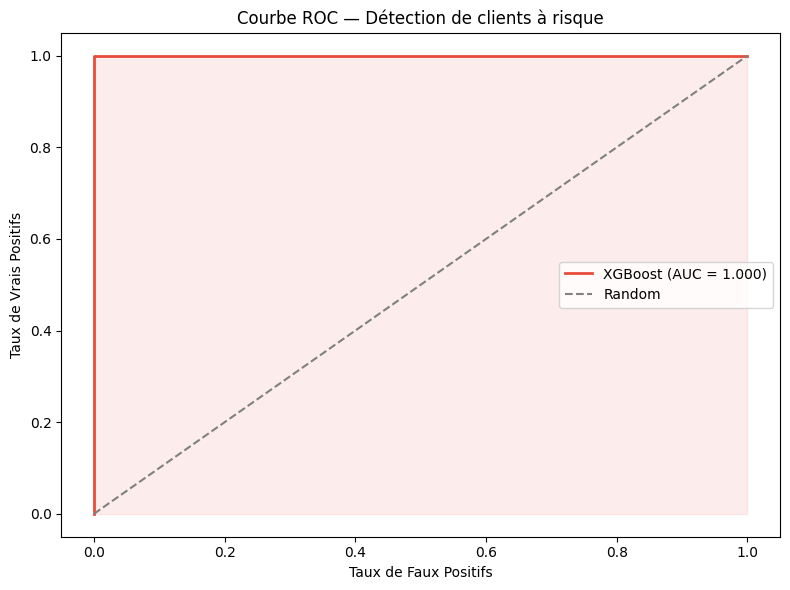


✅ AUC = 1.000
   → 0.5 = modèle aléatoire
   → 1.0 = modèle parfait
   → > 0.8 = bon modèle en production


In [18]:
# ================================
# XGBOOST + COURBE ROC
# ================================

!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Données
X = df[features].fillna(0)
y = df['is_risky']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=len(y[y==0])/len(y[y==1]),
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train, y_train)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb, X, y, cv=cv, scoring='roc_auc')

print(f"📊 AUC moyen (5-fold CV) : {scores.mean():.3f} ± {scores.std():.3f}")

# Courbe ROC
y_proba = xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2,
         label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC — Détection de clients à risque')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n✅ AUC = {roc_auc:.3f}")
print("   → 0.5 = modèle aléatoire")
print("   → 1.0 = modèle parfait")
print("   → > 0.8 = bon modèle en production")


✅ AUC corrigé (sans leakage) : 0.528


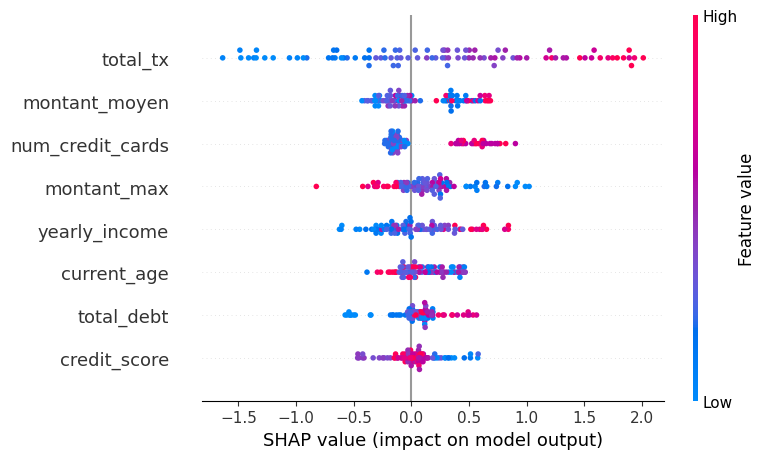

In [19]:
# ================================
# CORRECTION DATA LEAKAGE + SHAP
# ================================

!pip install shap -q
import shap

# Features SANS total_fraud et taux_fraude
# (sinon le modèle "triche")
features_clean = [
    'total_tx', 'montant_moyen', 'montant_max',
    'credit_score', 'yearly_income',
    'total_debt', 'current_age', 'num_credit_cards'
]

# Ajouter current_age et num_credit_cards depuis users
df2 = df.copy()

X = df2[features_clean].fillna(0)
y = df2['is_risky']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3,
    random_state=42, stratify=y)

# XGBoost sans leakage
xgb2 = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    scale_pos_weight=len(y[y==0])/len(y[y==1]),
    random_state=42,
    verbosity=0
)
xgb2.fit(X_train, y_train)

# AUC réel
y_proba2 = xgb2.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba2)
roc_auc2 = auc(fpr, tpr)
print(f"✅ AUC corrigé (sans leakage) : {roc_auc2:.3f}")

# SHAP Values
explainer = shap.TreeExplainer(xgb2)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=features_clean,
                  show=True)


✅ Clients normaux : 272
🚨 Clients anomalies : 31

📊 Croisement Isolation Forest vs is_risky :
Is Risky           0    1
Isolation Forest         
Anomalie           5   26
Normal            52  220


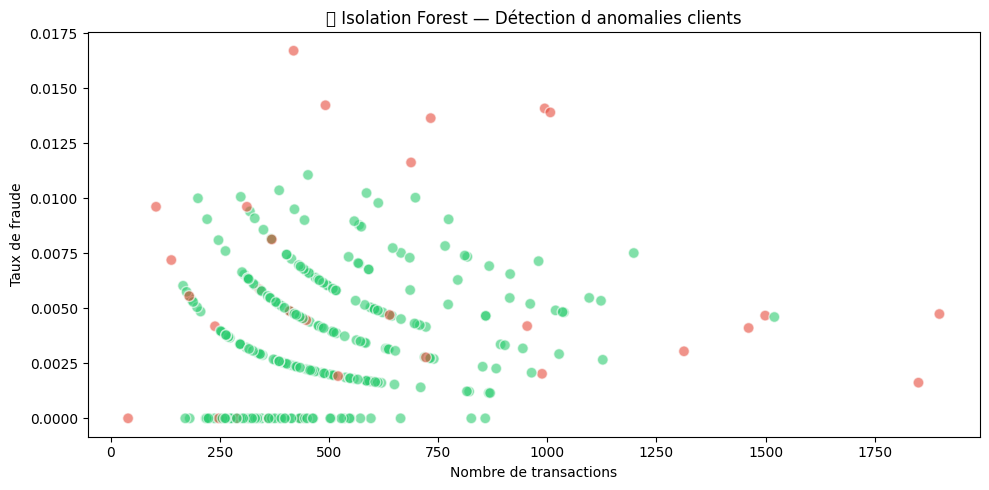

In [20]:
# ================================
# ISOLATION FOREST
# ================================

from sklearn.ensemble import IsolationForest

# Features pour détecter les anomalies
features_if = ['total_tx', 'montant_moyen',
               'montant_max', 'taux_fraude',
               'credit_score', 'yearly_income']

X_if = df[features_if].fillna(0)

# Isolation Forest
# contamination = % d'anomalies attendues
iso = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

df['anomalie'] = iso.fit_predict(X_if)
df['anomalie_score'] = iso.score_samples(X_if)

# -1 = anomalie, 1 = normal
df['anomalie_label'] = df['anomalie'].map({1: 'Normal', -1: 'Anomalie'})

print(f"✅ Clients normaux : {(df['anomalie']==1).sum()}")
print(f"🚨 Clients anomalies : {(df['anomalie']==-1).sum()}")

# Comparaison avec notre variable is_risky
print("\n📊 Croisement Isolation Forest vs is_risky :")
print(pd.crosstab(df['anomalie_label'], df['is_risky'],
      rownames=['Isolation Forest'],
      colnames=['Is Risky']))

# Visualisation
plt.figure(figsize=(10, 5))
colors = df['anomalie'].map({1: '#2ecc71', -1: '#e74c3c'})
plt.scatter(df['total_tx'], df['taux_fraude'],
            c=colors, alpha=0.6, edgecolors='white', s=60)
plt.xlabel('Nombre de transactions')
plt.ylabel('Taux de fraude')
plt.title('🔮 Isolation Forest — Détection d anomalies clients')
plt.tight_layout()
plt.show()


✅ Vélocité calculée !

🚨 Clients avec tx rapides ET fraude :
   67 clients identifiés


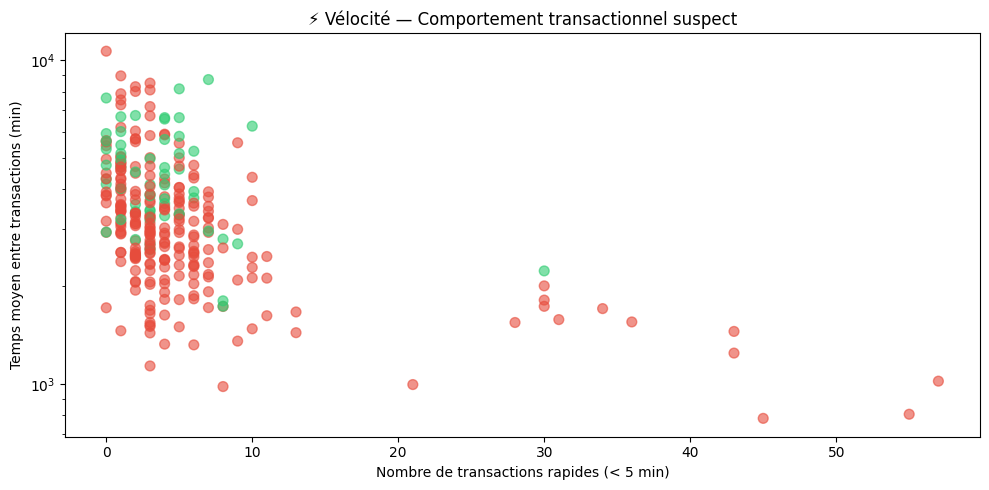


⚡ Temps minimum entre 2 tx : 0.0 min
📊 Moyenne tx rapides par client : 5.2


In [21]:
# ================================
# VÉLOCITÉ DES TRANSACTIONS
# ================================

# Trier par client et date
tx_sorted = tx.sort_values(['client_id', 'date'])

# Temps entre deux transactions consécutives
tx_sorted['temps_precedent'] = tx_sorted.groupby(
    'client_id')['date'].diff().dt.total_seconds() / 60

# Transactions rapides = moins de 5 minutes
tx_sorted['tx_rapide'] = (tx_sorted['temps_precedent'] < 5).astype(int)

# Agrégation par client
velocite = tx_sorted.groupby('client_id').agg(
    nb_tx_rapides=('tx_rapide', 'sum'),
    temps_moyen_entre_tx=('temps_precedent', 'mean'),
    temps_min_entre_tx=('temps_precedent', 'min')
).reset_index()

# Lien avec la fraude
velocite_fraud = tx_sorted.groupby('client_id')['is_fraud'].sum().reset_index()
velocite = velocite.merge(velocite_fraud, on='client_id')

print("✅ Vélocité calculée !")
print(f"\n🚨 Clients avec tx rapides ET fraude :")
risky_velocity = velocite[
    (velocite['nb_tx_rapides'] > 5) &
    (velocite['is_fraud'] > 0)]
print(f"   {len(risky_velocity)} clients identifiés")

# Visualisation
plt.figure(figsize=(10, 5))
colors = velocite['is_fraud'].apply(
    lambda x: '#e74c3c' if x > 0 else '#2ecc71')
plt.scatter(velocite['nb_tx_rapides'],
            velocite['temps_moyen_entre_tx'],
            c=colors, alpha=0.6, s=50)
plt.xlabel('Nombre de transactions rapides (< 5 min)')
plt.ylabel('Temps moyen entre transactions (min)')
plt.title('⚡ Vélocité — Comportement transactionnel suspect')
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"\n⚡ Temps minimum entre 2 tx : {velocite['temps_min_entre_tx'].min():.1f} min")
print(f"📊 Moyenne tx rapides par client : {velocite['nb_tx_rapides'].mean():.1f}")


In [22]:
# ================================
# DASHBOARD PLOTLY INTERACTIF
# ================================

!pip install plotly -q
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        '🕐 Fraude par heure',
        '📅 Fraude par jour',
        '⚡ Vélocité vs Fraude',
        '🔮 Isolation Forest'
    ]
)

# 1. Fraude par heure
fraude_heure = tx.groupby('heure')['is_fraud'].mean() * 100
fig.add_trace(go.Scatter(
    x=fraude_heure.index,
    y=fraude_heure.values,
    mode='lines+markers',
    line=dict(color='#e74c3c', width=2),
    fill='tozeroy',
    fillcolor='rgba(231,76,60,0.1)',
    name='Taux fraude/heure'
), row=1, col=1)

# 2. Fraude par jour
fraude_jour = tx.groupby('jour_semaine')['is_fraud'].mean() * 100
fraude_jour = fraude_jour.reindex([
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'])
fig.add_trace(go.Bar(
    x=fraude_jour.index,
    y=fraude_jour.values,
    marker_color=['#e74c3c' if j in ['Saturday','Sunday']
                  else '#3498db' for j in fraude_jour.index],
    name='Taux fraude/jour'
), row=1, col=2)

# 3. Vélocité vs Fraude
fig.add_trace(go.Scatter(
    x=velocite['nb_tx_rapides'],
    y=velocite['is_fraud'],
    mode='markers',
    marker=dict(
        color=velocite['is_fraud'],
        colorscale='Reds',
        size=6,
        opacity=0.6
    ),
    name='Vélocité'
), row=2, col=1)

# 4. Isolation Forest
colors_if = df['anomalie'].map({1: '#2ecc71', -1: '#e74c3c'})
fig.add_trace(go.Scatter(
    x=df['total_tx'],
    y=df['taux_fraude'],
    mode='markers',
    marker=dict(
        color=df['anomalie'].map({1: '#2ecc71', -1: '#e74c3c'}),
        size=6,
        opacity=0.6
    ),
    name='Anomalies'
), row=2, col=2)

# Layout
fig.update_layout(
    title_text='🏦 Aurora Bank — Fraud Detection Dashboard',
    title_font_size=20,
    height=700,
    showlegend=False,
    template='plotly_white'
)

fig.show()
print("✅ Dashboard interactif généré !")


✅ Dashboard interactif généré !


In [23]:
# ================================
# FASTAPI — FRAUD DETECTION API
# ================================


api_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import numpy as np
import pickle

app = FastAPI(
    title="Aurora Bank — Fraud Detection API",
    description="API de scoring de risque fraude bancaire",
    version="1.0.0"
)

# Modèle de données entrante
class Transaction(BaseModel):
    client_id: int
    total_tx: float
    montant_moyen: float
    montant_max: float
    credit_score: float
    yearly_income: float
    total_debt: float
    current_age: float
    num_credit_cards: float

class ClientProfile(BaseModel):
    client_id: int
    nb_tx_rapides: float
    temps_moyen_entre_tx: float

# Route principale
@app.get("/")
def home():
    return {
        "message": "Aurora Bank Fraud Detection API",
        "version": "1.0.0",
        "endpoints": ["/predict", "/velocity", "/health"]
    }

# Prédiction de risque
@app.post("/predict")
def predict_fraud(transaction: Transaction):
    features = [[
        transaction.total_tx,
        transaction.montant_moyen,
        transaction.montant_max,
        transaction.credit_score,
        transaction.yearly_income,
        transaction.total_debt,
        transaction.current_age,
        transaction.num_credit_cards
    ]]

    score = xgb2.predict_proba(features)[0][1]
    risk_level = "HIGH" if score > 0.7 else "MEDIUM" if score > 0.4 else "LOW"

    return {
        "client_id": transaction.client_id,
        "fraud_score": round(float(score), 3),
        "risk_level": risk_level,
        "recommendation": (
            "Bloquer la transaction" if risk_level == "HIGH"
            else "Surveillance renforcée" if risk_level == "MEDIUM"
            else "Transaction normale"
        )
    }

# Analyse vélocité
@app.post("/velocity")
def check_velocity(profile: ClientProfile):
    is_suspicious = (
        profile.nb_tx_rapides > 5 and
        profile.temps_moyen_entre_tx < 10
    )
    return {
        "client_id": profile.client_id,
        "nb_tx_rapides": profile.nb_tx_rapides,
        "suspicious_velocity": is_suspicious,
        "alert": "Comportement suspect détecté !" if is_suspicious else "Normal"
    }

# Health check
@app.get("/health")
def health():
    return {"status": "online", "model": "XGBoost v1.0"}
'''

print(api_code)
print("\n✅ Code FastAPI prêt !")
print("📁 Pour déployer sur PC :")
print("   1. pip install fastapi uvicorn")
print("   2. Coller ce code dans main.py")
print("   3. uvicorn main:app --reload")
print("   4. Ouvrir http://localhost:8000/docs")



from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import numpy as np
import pickle

app = FastAPI(
    title="Aurora Bank — Fraud Detection API",
    description="API de scoring de risque fraude bancaire",
    version="1.0.0"
)

# Modèle de données entrante
class Transaction(BaseModel):
    client_id: int
    total_tx: float
    montant_moyen: float
    montant_max: float
    credit_score: float
    yearly_income: float
    total_debt: float
    current_age: float
    num_credit_cards: float

class ClientProfile(BaseModel):
    client_id: int
    nb_tx_rapides: float
    temps_moyen_entre_tx: float

# Route principale
@app.get("/")
def home():
    return {
        "message": "Aurora Bank Fraud Detection API",
        "version": "1.0.0",
        "endpoints": ["/predict", "/velocity", "/health"]
    }

# Prédiction de risque
@app.post("/predict")
def predict_fraud(transaction: Transaction):
    features = [[
        transaction.total_tx,
        transaction.